In [14]:
import numpy as np

def two_body_decay(M, m1, m2):
   
    term1 = M**2 - (m1 + m2)**2
    term2 = M**2 - (m1 - m2)**2
    p = np.sqrt(term1 * term2) / (2 * M)

    cos_theta = np.random.uniform(-1, 1)
    theta = np.arccos(cos_theta)
    phi = np.random.uniform(0, 2*np.pi)
    
    px = p * np.sin(theta) * np.cos(phi)
    py = p * np.sin(theta) * np.sin(phi)
    pz = p * cos_theta

    p1 = np.array([px, py, pz])
    p2 = -p1

    E1 = np.sqrt(p**2 + m1**2)
    E2 = np.sqrt(p**2 + m2**2)

    return (E1, p1), (E2, p2)

def invariant_mass(E1, p1, E2, p2):
    E = E1 + E2
    p = p1 + p2
    return np.sqrt(E**2 - np.dot(p, p))


def expected_dedx(p, mass):
    beta = p / np.sqrt(p**2 + mass**2)
    return 1 / beta**2  # uproszczenie
def nsigma(measured, expected, sigma=0.05):
    return (measured - expected) / sigma

import matplotlib.pyplot as plt

def smear_momentum(p, resolution=0.05):
    """Symuluje rozdzielczość pędu detektora"""
    smear = np.random.normal(0, resolution)
    return p * (1 + smear)

M = 3.096  # GeV (J/psi)
m_mu = 0.105

N = 10000

masses = []
thetas = []
phis = []

for _ in range(N):
    (E1, p1), (E2, p2) = two_body_decay(M, m_mu, m_mu)

    p1_s = smear_momentum(p1)
    p2_s = smear_momentum(p2)

    E1_s = np.sqrt(np.dot(p1_s, p1_s) + m_mu**2)
    E2_s = np.sqrt(np.dot(p2_s, p2_s) + m_mu**2)

    m = invariant_mass(E1_s, p1_s, E2_s, p2_s)
    masses.append(m)

    p = np.linalg.norm(p1)
    theta = np.arccos(p1[2] / p)
    phi = np.arctan2(p1[1], p1[0])

    thetas.append(theta)
    phis.append(phi)


(array([  1.,   0.,   0.,   1.,   3.,   1.,   4.,   4.,   3.,   3.,   2.,
          3.,   5.,  10.,  10.,  13.,   8.,  14.,  19.,  23.,  18.,  41.,
         31.,  42.,  47.,  45.,  57.,  63.,  78.,  85.,  93., 121., 111.,
         96., 149., 184., 165., 195., 185., 196., 203., 230., 248., 259.,
        269., 286., 261., 269., 302., 301., 299., 259., 304., 266., 276.,
        281., 231., 250., 254., 237., 241., 210., 204., 195., 185., 189.,
        143., 140., 130., 112., 107.,  83., 105.,  78.,  70.,  50.,  44.,
         42.,  51.,  29.,  25.,  23.,  22.,  24.,  24.,  11.,  10.,  11.,
          2.,   4.,   6.,   4.,   4.,   0.,   2.,   2.,   0.,   1.,   1.,
          2.]),
 array([2.69093164, 2.69884652, 2.70676141, 2.7146763 , 2.72259118,
        2.73050607, 2.73842095, 2.74633584, 2.75425072, 2.76216561,
        2.77008049, 2.77799538, 2.78591026, 2.79382515, 2.80174003,
        2.80965492, 2.8175698 , 2.82548469, 2.83339958, 2.84131446,
        2.84922935, 2.85714423, 2.86505912, 2.

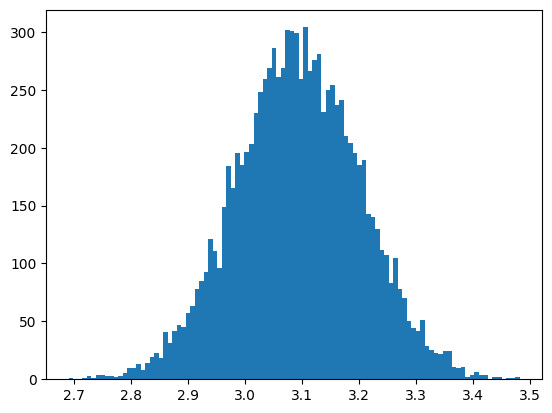

In [15]:
plt.hist(masses, bins=100)

In [16]:
import numpy as np

def bethe_bloch_like(p, m, K=1.0):
    """
    uproszczona krzywa BB (kształt realistyczny, nie absolutne jednostki)
    """
    E = np.sqrt(p**2 + m**2)
    beta = p / E

    # avoid divergence
    beta = np.clip(beta, 1e-6, 0.999999)

    # BB-like shape
    dedx = (1 / beta**2) * np.log(1 + beta**2 * 10)

    return K * dedx

In [17]:
def tpc_measurement(dedx_true, resolution=0.07):
    """
    symulacja rozdzielczości TPC (~5-10%)
    log-normal noise jak w realu
    """
    return dedx_true * np.exp(np.random.normal(0, resolution))

In [18]:
def nsigma_tpc(p, mass, dedx_meas, sigma=0.07):
    dedx_exp = bethe_bloch_like(p, mass)

    return (np.log(dedx_meas) - np.log(dedx_exp)) / sigma

In [19]:
masses = {
    "pi": 0.139,
    "K": 0.494,
    "p": 0.938
}

In [20]:
p = 1.0  # GeV

true_particle = "K"

dedx_true = bethe_bloch_like(p, masses[true_particle])
dedx_meas = tpc_measurement(dedx_true)

for name, m in masses.items():
    nsig = nsigma_tpc(p, m, dedx_meas)
    print(name, nsig)

pi 1.8457311182730258
K 0.11663869279148831
p -3.2469196060676375


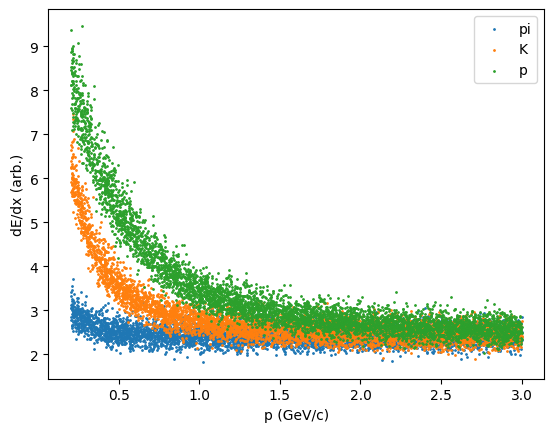

In [21]:
import matplotlib.pyplot as plt

N = 5000
ps = np.random.uniform(0.2, 3, N)

dedx_pi, dedx_K, dedx_p = [], [], []

for p in ps:
    dedx_pi.append(tpc_measurement(bethe_bloch_like(p, masses["pi"])))
    dedx_K.append(tpc_measurement(bethe_bloch_like(p, masses["K"])))
    dedx_p.append(tpc_measurement(bethe_bloch_like(p, masses["p"])))

plt.scatter(ps, dedx_pi, s=1, label="pi")
plt.scatter(ps, dedx_K, s=1, label="K")
plt.scatter(ps, dedx_p, s=1, label="p")

plt.xlabel("p (GeV/c)")
plt.ylabel("dE/dx (arb.)")
plt.legend()
plt.show()